In [2]:
import jax
import jax.numpy as jnp
from torchquad import MonteCarlo, Boole, VEGAS
from torchquad import set_up_backend  # Necessary to enable GPU support
set_up_backend("jax", data_type="float32")


def get_interpolated(k, p):

  x_data_jax = jnp.array(k)
  y_data_jax = jnp.array(p)

  @jax.jit
  def interpolate_function(x_new):
      # For 1D linear interpolation
      return jnp.interp(x_new, x_data_jax, y_data_jax)

  return interpolate_function


def integrate(Ks, function, batch_size = 5):
  """
  Integrate function for each mode K in Ks.
  """
  #batch_size = 5 # if Ks.size > 20 else 10
  results = []
  for i in range(0, len(Ks), batch_size):
      batch_Ks = jnp.array(Ks[i:i+batch_size])
      batch_results = jax.vmap(function)(batch_Ks)
      results.append(batch_results)
  results = jnp.concatenate(results)
  return results


def set_up_fixed_grid(N, dim, integration_domain):
  integration_domain = jnp.array(integration_domain)
  integrator = MonteCarlo()
  grid_points, hs, n_per_dim = integrator.calculate_grid(N, integration_domain)


def dot(k1, k2):
   return jnp.sum(k1*k2, axis=-1)

def cosine_angle(k1, k2, k1_mag, k2_mag):
    dot_product = dot(k1, k2)
    cos_angle = dot_product / (k1_mag * k2_mag)
    return cos_angle


def spherical_to_cartesian(phi, mu, k_mag):
    """
    Convert from spherical coordinates to Cartesian coordinates.

    Parameters:
    phi: azimuthal angle (in the x-y plane)
    mu: cosine of the polar angle (mu = cos(theta))
    k_mag: magnitude of the vector

    Returns:
    k_vec: Cartesian coordinates (x, y, z)
    """
    # Calculate sine of the polar angle from mu
    sin_theta = jnp.sqrt(1 - mu**2)

    # Calculate the Cartesian components
    x = k_mag * sin_theta * jnp.cos(phi)
    y = k_mag * sin_theta * jnp.sin(phi)
    z = k_mag * mu

    # Stack the components into a single vector
    k_vec = jnp.c_[x, y, z]

    return k_vec


def get_k1_k2_mask(K, k, phi, mu, kmin, kmax):

  K_minus_k = jnp.sqrt(K**2+k**2-2*K*k*mu)

  K = spherical_to_cartesian(phi*0, mu*0+1, K) #[0, 0, K], aligned with z-axis
  k1 = spherical_to_cartesian(phi, mu, k)
  k2 = K-k1

  mask = (k>=kmin) & (k<=kmax)
  mask_2 = (K_minus_k>=kmin) & (K_minus_k<=kmax)
  mask *= mask_2

  return k1, k2, mask


def bs2_coev(b10):
  """
  Coevolution value of the bs2 parameter
  """
  return -2./7.*(b10-1)

def get_f(F, P_linear, a, b):
  """
  Returns function for f = 2[F(k1+k2, -k1)P(|k1|)+F(k1+k2, -k2)P(k2)]
  """
  @jax.jit
  def f(k1, k2):
    K = k1+k2
    K_mag = jnp.linalg.norm(K, axis=-1)
    k1_mag = jnp.linalg.norm(k1, axis=-1)
    k2_mag = jnp.linalg.norm(k2, axis=-1)

    mu_1 = -cosine_angle(K, k1, K_mag, k1_mag)
    mu_2 = -cosine_angle(K, k2, K_mag, k2_mag)

    result = 2*(a*F(q1 = K_mag, q2 = k1_mag, mu = mu_1)*P_linear(k1_mag)+b*F(q1 = K_mag, q2 = k2_mag, mu = mu_2)*P_linear(k2_mag))
    return result
  return f


def N_per_mode(f_jax_A: callable, f_jax_B: callable, P_AA: callable, P_BB: callable,
               kmin: float = 0.015, kmax: float = 0.15, Ndim = 2, Nsamples_base = 10000):
    """
    Returns calculation of noise normalization per mode
    """

    @jax.jit
    def single_calculation(K):
        def integrand(x):
            # Calculate N(K) = \int_{\vec{k}} [(P(k)+P(K-k))]^2/(PAA(k)*PBB(K-k))
            mu, k = x[:, 0], x[:, 1]

            phi_vol = 2*jnp.pi
            volume = phi_vol*k**2/(2*jnp.pi)**3

            k1, k2, mask = get_k1_k2_mask(K, k, mu*0, mu, kmin, kmax)
            k1_mag, k2_mag = jnp.linalg.norm(k1, axis=-1), jnp.linalg.norm(k2, axis=-1)

            fresultA = f_jax_A(k1, k2)

            fresultB = f_jax_B(k1, k2)

            return fresultA*fresultB/(2*P_AA(k1_mag)*P_BB(k2_mag))*volume*mask

        N = Nsamples_base**Ndim+1

        mc = MonteCarlo()
        result = mc.integrate(integrand, dim = Ndim, N = N,
                              integration_domain = [[-1, 1], [kmin, kmax]],
                              backend = "jax")
        return result

    return single_calculation


def get_w(f, P_AA, P_BB):
      """
      Weight function w that depends on f and the total power spectra of tracers.

      The weight is given by: f/(2*PAA_tot(k1)*PBB_tot(k2))

      This implementation is optimized for batch processing with Vegas integration.
      It assumes k1 and k2 are 3D vectors, potentially with batch dimensions.
      """

      @jax.jit
      def w(k1, k2):
          # Calculate magnitudes
          k1_mag = jnp.linalg.norm(k1, axis=-1)
          k2_mag = jnp.linalg.norm(k2, axis=-1)

          # Get the f function value using vectors
          f_value = f(k1, k2)

          # Get power spectrum values for the tracers
          P_AA_value = P_AA(k1_mag)
          P_BB_value = P_BB(k2_mag)

          # w_α(k1,k2) = f_α(k1,k2) / (2*PAA_tot(k1)*PBB_tot(k2))
          denominator = 2.0 * P_AA_value * P_BB_value

          result = f_value / denominator
          return result

      return w



def variance_per_mode(weight_AB_alpha: callable, weight_XY_beta: callable,
                      P_AX: callable, P_BY: callable, P_AY: callable, P_BX: callable, kmin: float = 0.051, kmax: float = 0.15,
                      Nsamples_base = 1000, Ndim = 3):
    """
    This calculates the noise between two estimator h^{AB}_alpha, h^{XY}_beta built with A, B, X, Y tracers, for alpha, beta estimation.


    """

    def single_calculation(K):
        @jax.jit
        def integrand(x):
            phi, mu, k = x[:, 0], x[:, 1], x[:, 2]

            volume = k**2/(2*jnp.pi)**3

            k1, k2, mask = get_k1_k2_mask(K, k, phi, mu, kmin, kmax)
            k1_mag, k2_mag = jnp.linalg.norm(k1, axis=-1), jnp.linalg.norm(k2, axis=-1)

            w_result_AB = weight_AB_alpha(k1, k2)
            w_result_XY_1 = weight_XY_beta(k1, k2)
            w_result_XY_2 = weight_XY_beta(k2, k1)
            P_AX_value = P_AX(k1_mag)
            P_BY_value = P_BY(k2_mag)
            P_AY_value = P_BY(k1_mag)
            P_BX_value = P_BX(k2_mag)

            result = w_result_XY_1*P_AX_value*P_BY_value+w_result_XY_2*P_AY_value*P_BX_value
            result *= w_result_AB

            return result*volume*mask

        N = Nsamples_base**Ndim+1


        integration_domain = [[0, 2*jnp.pi], [-1, 1], [kmin, kmax]]

        mc = MonteCarlo()
        result = mc.integrate(integrand, dim = Ndim, N = N,
                              integration_domain = integration_domain,
                              backend = "jax")
        return result

    return single_calculation



def variance_per_mode_integrand(K: float, weight_AB_alpha: callable, weight_XY_beta: callable,
                      P_AX: callable, P_BY: callable, P_AY: callable, P_BX: callable, kmin: float = 0.051, kmax: float = 0.15,
                      Nsamples_base = 1000, Ndim = 3):
    """
    This calculates the noise between two estimator h^{AB}_alpha, h^{XY}_beta built with A, B, X, Y tracers, for alpha, beta estimation.


    """


    @jax.jit
    def integrand(x):
        phi, mu, k = x[:, 0], x[:, 1], x[:, 2]

        volume = k**2/(2*jnp.pi)**3

        k1, k2, mask = get_k1_k2_mask(K, k, phi, mu, kmin, kmax)
        k1_mag, k2_mag = jnp.linalg.norm(k1, axis=-1), jnp.linalg.norm(k2, axis=-1)

        w_result_AB = weight_AB_alpha(k1, k2)
        w_result_XY_1 = weight_XY_beta(k1, k2)
        w_result_XY_2 = weight_XY_beta(k2, k1)
        P_AX_value = P_AX(k1_mag)
        P_BY_value = P_BY(k2_mag)
        P_AY_value = P_BY(k1_mag)
        P_BX_value = P_BX(k2_mag)

        result = w_result_XY_1*P_AX_value*P_BY_value+w_result_XY_2*P_AY_value*P_BX_value
        result *= w_result_AB

        return result*volume*mask

    return integrand


"""def set_up_fixed_grid(N, dim, integration_domain):
  integration_domain = jnp.array(integration_domain)
  integrator = MonteCarlo()
  grid_points = integrator.calculate_sample_points(N, integration_domain)
  return integrator, grid_points

N = int(1e5)
dim = 3
kmin, kmax = 0.05, 0.15
integration_domain = jnp.array([[0, 2*jnp.pi], [-1, 1], [kmin, kmax]])

integrator, grid_points = set_up_fixed_grid(N, dim, integration_domain)

for K in Ks:
  integrand = variance_per_mode_integrand(K, w_A, w_B, P_AX = P_AA, P_BY = P_BB, P_AY = P_AB, P_BX = P_AB, kmin = kmin, kmax = kmax, Nsamples_base = 200)
  function_values, _ = integrator.evaluate_integrand(integrand, grid_points)
  integral1 = integrator.calculate_result(function_values, integration_domain)
"""



def cross_shot_mixed_AAB(weight_AB_alpha: callable, nbar_A: float, P_AB: callable,
               kmin: float = 0.015, kmax: float = 0.15, Ndim = 2, Nsamples_base = 10000):
    """
    Returns calculation of mixed shot noise
    """

    @jax.jit
    def single_calculation(K):
        def integrand(x):
            mu, k = x[:, 0], x[:, 1]

            phi_vol = 2*jnp.pi
            volume = phi_vol*k**2/(2*jnp.pi)**3

            k1, k2, mask = get_k1_k2_mask(K, k, mu*0, mu, kmin, kmax)
            k2_mag = jnp.linalg.norm(k2, axis=-1)

            w_result_AB = weight_AB_alpha(k1, k2)
            shotA = 1/nbar_A
            PS = P_AB(k2_mag)*shotA

            return w_result_AB*PS*volume*mask

        N = Nsamples_base**Ndim+1

        mc = MonteCarlo()
        result = mc.integrate(integrand, dim = Ndim, N = N,
                              integration_domain = [[-1, 1], [kmin, kmax]],
                              backend = "jax")
        return result

    return single_calculation



def Fs(k1, k2):
  return 0.5*(1/np.linalg.norm(k1, axis = 0)**2+1/np.linalg.norm(k2, axis = 0)**2)*dot(k1, k2)

def Ft(k1, k2):
  return 2/7*(dot(k1, k2)**2/np.linalg.norm(k1, axis = 0)/np.linalg.norm(k2, axis = 0)-1/3)

def Fg(k1, k2):
  return 17/21

def bispectrum_XYZ(k1, k2, k3, P_signal_X, P_signal_Y, P_signal_Z, Fkernels, Fbiases):
  P_X_1 = P_signal_X(k1)
  P_Y_2 = P_signal_Y(k2)
  P_Z_3 = P_signal_Z(k3)

  XY = 2*P_X_1*P_Y_2*np.sum([F(k1, k2)*c for F, c in zip(Fkernels, Fbiases)], axis = 0)
  YZ = 2*P_Y_2*P_Z_3*np.sum([F(k2, k3)*c for F, c in zip(Fkernels, Fbiases)], axis = 0)
  XZ = 2*P_X_1*P_Z_3*np.sum([F(k1, k3)*c for F, c in zip(Fkernels, Fbiases)], axis = 0)

  somma = XY+YZ+XZ
  return somma




def variance_per_mode_integrand(K: float, weight_AB_alpha: callable, weight_XY_beta: callable,
                      P_AX: callable, P_BY: callable, P_AY: callable, P_BX: callable, kmin: float = 0.051, kmax: float = 0.15,
                      Nsamples_base = 1000, Ndim = 3):
    """
    This calculates the noise between two estimator h^{AB}_alpha, h^{XY}_beta built with A, B, X, Y tracers, for alpha, beta estimation.


    """


    @jax.jit
    def integrand(x):
        phi, mu, k = x[:, 0], x[:, 1], x[:, 2]

        volume = k**2/(2*jnp.pi)**3

        k1, k2, mask = get_k1_k2_mask(K, k, phi, mu, kmin, kmax)
        k1_mag, k2_mag = jnp.linalg.norm(k1, axis=-1), jnp.linalg.norm(k2, axis=-1)

        w_result_AB = weight_AB_alpha(k1, k2)
        w_result_XY_1 = weight_XY_beta(k1, k2)
        w_result_XY_2 = weight_XY_beta(k2, k1)
        P_AX_value = P_AX(k1_mag)
        P_BY_value = P_BY(k2_mag)
        P_AY_value = P_BY(k1_mag)
        P_BX_value = P_BX(k2_mag)

        result = w_result_XY_1*P_AX_value*P_BY_value+w_result_XY_2*P_AY_value*P_BX_value
        result *= w_result_AB

        return result*volume*mask

    return integrand

In [ ]:
import numpy as np
import sympy as sp
import sympy2jax

knl, pnl = np.loadtxt("nonlinear_power_quijote.txt").T
kl, pl = np.loadtxt("linear_power_quijote.txt").T

interpolate_function = get_interpolated(knl, pnl)
interpolate_function_lin = get_interpolated(kl, pl)

q1, q2, mu = sp.symbols('q1 q2 mu')



def get_total_P(b10, nbar):
  shot = 1/nbar
  return jax.jit(lambda k: b10**2*interpolate_function(k)+shot)


b10_A = 1 #1.6
nbar_A = 3.3e-4
b10_B = 1 #1.6
nbar_B = 3.3e-4

P_AA = get_total_P(b10_A, nbar_A)
P_BB = get_total_P(b10_B, nbar_B)
P_AB = jax.jit(lambda k: b10_A*b10_B*interpolate_function(k))
P_linear = jax.jit(lambda k: interpolate_function_lin(k))



deltac = 1.42
# a1 = 1 in spherical collapse
a1 = 1.
# a2 = -17/21 in spherical collapse
a2 = -0.8095238095

Fg_factor = 17/21
Ft_one_third = True

"""cgs = {}
cgs["g"] = lambda b1, b2, bs2: b1+Fg_factor**-1*b2
cgs["s"] = lambda b1, b2, bs2: b1
cgs["t"] = lambda b1, b2, bs2: b1+7/2*bs2
cgs["x"] = lambda b1, b2, bs2: b1
cgs["n"] = lambda b1, b2, bs2: b1
cgs["phiphi"] = lambda b1, fnl: b1*fnl
cgs["c01"] = lambda b1, fnl: fnl*2*deltac*(b1-1.)
cgs["c11"] = lambda b1, b2, fnl: fnl*(2./a1)*(deltac*(b2-2*(a1+a2)*(b1-1.))-a1**2.*(b1-1.))+2.*fnl*deltac*(b1-1.)
cgs["c02"] = lambda b1, b2, fnl: fnl**2*4*deltac*((deltac/a1**2.)*(b2-2.*(a1+a2)*(b1-1.))-2.*(b1-1.))"""


Cg = {}
Cg["g"] = lambda b1A, b2A, b1B, bthetaA, bdeltathetaA, fX, bmrA, brA: (Fg_factor*b1A+1/2*b2A)*b1B
Cg["s"] = lambda b1A, b2A, bs2A, b1B, b2B, bs2B: b1A*b1B
Cg["t"] = lambda b1A, b2A, bs2A, b1B, b2B, bs2B: (2/7*b1A+1/2*bs2A)*b1B
Cg["n"] = lambda b1A, b2A, bs2A, b1B, b2B, bs2B: 1*(b1A==b1B)
Cg["x"] = lambda b1A, epsilon, brB, bDB, bthetaB, H: b1A*epsilon*(17/6*brB-7/3*H*bthetaB-5/3*H*bDB)
Cg["phiphi"] = lambda b1A, b1B, fnl: b1A*fnl


b20_A = 0 #-0.3
b20_B = 0 #-0.3

bthetaB = 0.5
bthetaA = 0.3

brA = 1
brB = 2

epsilon = 1e-3
epsilon_2 = 10*epsilon

bs2f = lambda b10: -2./7.*(b10-1)

bs2_A = 1 #bs2f(b10_A)
bs2_B = 1 #bs2f(b10_B)

fX = 1
bmrA, bdeltathetaA = 0, 0
bmrB, bdeltathetaB = 0, 0

estimator_configs = {
        'g': {
            'F': Fg_factor*q1/q1,
            'ca': Cg["g"](b1A = b10_A, b2A = b20_A, b1B = b10_B, bthetaA = 0, bdeltathetaA = 0, fX = 0, bmrA = 0, brA = 0), #AB
            'cb': Cg["g"](b1A = b10_B, b2A = b20_B, b1B = b10_A, bthetaA = 0, bdeltathetaA = 0, fX = 0, bmrA = 0, brA = 0) #BA
        },
        's': {
            'F': 0.5*(q2/q1+q1/q2)*mu, #NOTE: MU IS ALWAYS THE ANGLE BETWEEN Q1 AND Q2, BUT OFTEN IN THE CODE Q1 IS JUST K!
            'ca': Cg["s"](b1A = b10_A, b2A = 0, bs2A = 0, b1B = b10_B, b2B = 0, bs2B = 0),#b10,
            'cb': Cg["s"](b1A = b10_B, b2A = 0, bs2A = 0, b1B = b10_A, b2B = 0, bs2B = 0)#b10
        },
        't': {
            'F': (2./7.)*mu**2.-1./3.*(Ft_one_third),
            'ca': Cg["s"](b1A = b10_A, b2A = 0, bs2A = bs2_A, b1B = b10_B, b2B = 0, bs2B = 0),
            'cb': Cg["s"](b1A = b10_B, b2A = 0, bs2A = bs2_B, b1B = b10_A, b2B = 0, bs2B = 0)
        },
        'x': {
            #'F': 1/(q1+q2)*mu,
            'F': 0.5*(q2/q1+q1/q2)*mu,
            'ca': Cg["x"](b1A = b10_A, epsilon = epsilon, bthetaB = 0, brB = brB, bDB = 0, H = 0),
            'cb': Cg["x"](b1A = b10_B, epsilon = epsilon, bthetaB = 0, brB = brA, bDB = 0, H = 0)
        },
        'x1': {
            #'F': 1/(q1+q2)*mu,
            'F': 0.5*(q2/q1+q1/q2)*mu,
            'ca': Cg["x"](b1A = b10_A, epsilon = epsilon, bthetaB = 0, brB = brB, bDB = 0, H = 0),
            'cb': 0
        },
        'x2': {
            #'F': 1/(q1+q2)*mu,
            'F': 0.5*(q2/q1+q1/q2)*mu,
            'ca': 0,
            'cb': Cg["x"](b1A = b10_B, epsilon = epsilon, bthetaB = 0, brB = brA, bDB = 0, H = 0)
        },
        #'x2': {
            #'F': 1/(q1+q2)*mu,
        #    'F': 0.5*(q2/q1+q1/q2)*mu,
        #    'ca': Cg["x"](b1A = b10_A, epsilon = epsilon_2, bthetaB = 0, brB = brB, bDB = 0, H = 0),
        #    'cb': Cg["x"](b1A = b10_B, epsilon = epsilon_2, bthetaB = 0, brB = brA, bDB = 0, H = 0)
        #},
        'n': {
            #'F': 1/(q1+q2)*mu,
            'F': 0.5*mu*q2/q1,
            'ca': Cg["n"](1, 0, 0, 1, 0, 0),
            'cb': Cg["n"](1, 0, 0, 0, 0, 0)
        }
    }

estimator_lam = {key: sp.lambdify([q1, q2, mu], estimator_configs[key]['F'], 'numpy') for key in estimator_configs}
estimator_lam_jax = {key: sympy2jax.SymbolicModule(estimator_configs[key]['F']) for key in estimator_configs}



In [ ]:
f_jax = {key: get_f(estimator_lam_jax[key], P_linear, estimator_configs[key]["ca"], estimator_configs[key]["cb"]) for key in estimator_lam_jax}

In [ ]:
keypairs = [("x1" ,"n"), ("x2", "n"), ("n", "n"), ("s", "n"), ("g", "n"), ("x", "n"), ("t", "n"), ("g", "g")]#, ("g", "g"), ("s", "s")]


estimator_keys = ["n", "g", "x", "s", "t", "x2"]
estimator_pairs = []
for i, alpha in enumerate(estimator_keys):
    for beta in estimator_keys[i:]:  # Only compute upper triangle (including diagonal)
        estimator_pairs.append((alpha, beta))

In [ ]:
kmin, kmax = 0.051, 0.15

Ks = np.linspace(0.001, kmin-1e-3, 100)

#keypairs = [("g", "g")]

Nsamples_base = 10000

out = {}
out_variance = {}
out_cross_shot = {}
for keypair in keypairs:
  keyA, keyB = keypair
  N_single = N_per_mode(f_jax[keyA], f_jax[keyB], P_AA, P_BB, kmin, kmax, Nsamples_base = Nsamples_base)
  out[keypair] = integrate(Ks, N_single, batch_size = 2)

  w_A = get_w(f_jax[keyA], P_AA, P_BB)
  #w_B = get_w(f_jax[keyB], P_AA, P_BB)
  #variance_single = variance_per_mode(w_A, w_B, P_AX = P_AA, P_BY = P_BB, P_AY = P_AB, P_BX = P_AB, kmin = kmin, kmax = kmax, Nsamples_base = 200)
  #out_variance[keypair] = integrate(Ks, variance_single, batch_size = 5)

  cross_single = cross_shot_mixed_AAB(w_A, nbar_A, P_AB, kmin = kmin, kmax = kmax, Nsamples_base = Nsamples_base)
  out_cross_shot[keypair] = integrate(Ks, cross_single, batch_size = 2)



/usr/local/lib/python3.11/dist-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


In [ ]:
out_original = np.load("out.npy", allow_pickle = True).item()
#out_cross_original = np.load("out_cross_shot.npy", allow_pickle = True).item()

In [ ]:
import matplotlib.pyplot as plt

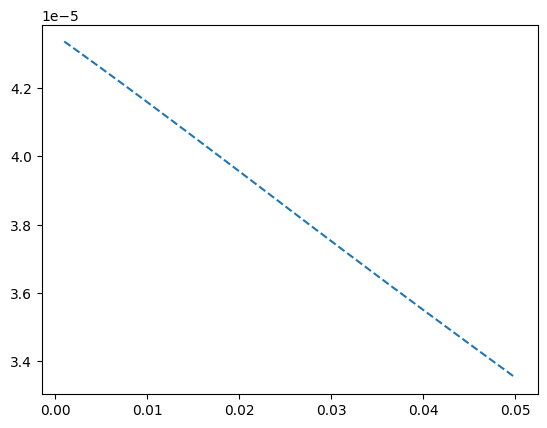

<ipython-input-11-fe459b363d4a>:11: RuntimeWarning: divide by zero encountered in reciprocal
  Norm_orig = out_original[keypair]**-1.


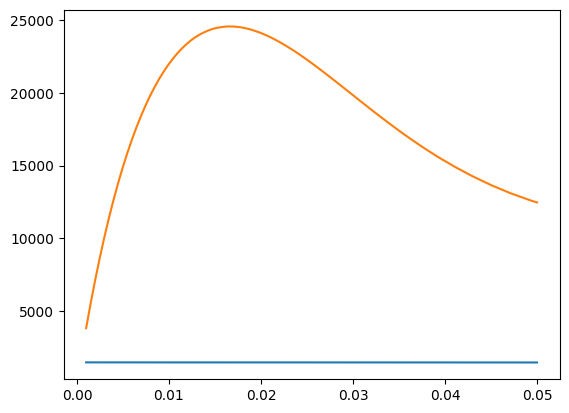

In [ ]:
key = "g"
keypair = (key, key)

#plt.loglog(out_original["Ks"], out_original[keypair])
plt.plot(Ks, out[keypair], ls = "--")
#plt.plot(Ks, out_variance[keypair], ls = ":")
#plt.xscale("log")
plt.show()

Norm = out[keypair]**-1.
Norm_orig = out_original[keypair]**-1.
#Norm_orig = np.interp(out_cross_original["Ks"], out_original["Ks"], Norm_orig)

#plt.plot(out_cross_original["Ks"], Norm_orig*out_cross_original[keypair], lw = 2)
plt.plot(Ks, Norm*out_cross_shot[keypair])
plt.plot(Ks, P_linear(Ks))
#plt.xscale("log")
plt.show()

In [ ]:
import sympy as sp
import numpy as np
import itertools
import matplotlib.pyplot as plt


class expression():
    # args here is just the list of variables used
    def __init__(self, *args):
        var_list = []
        var_list_names = []
        ns = {}
        for a in args:
            symb = sp.symbols(a)
            setattr(self, a, symb)
            ns[a] = symb
            var_list += [symb]
            var_list_names += [a]
        self.vars = var_list
        self.vars_names = var_list_names
        self.ns = ns

    def add_extra_var(self, name, expression):
        setattr(self, name, expression)

    # similar to add_extra_var but logic of usage is different
    def add_expression(self, expression_name: str, expr):
        setattr(self, expression_name, sp.sympify(expr, locals = self.ns))

    def __add__(self, other_object_expression):
        return

    def get_expression(self, expression_name):
        return getattr(self, expression_name)

    def evaluate_expression(self, expression_name, **valuesdict):
        expr = getattr(self, expression_name)
        expr_numpy = sp.lambdify(self.vars, expr, 'numpy')
        return expr_numpy(**valuesdict)

    def derivate(self, expression_name, variable_of_derivation, save_derivative = False):
        derivative = sp.diff(getattr(self, expression_name), variable_of_derivation)
        if save_derivative:
            der_expression_name = 'der'+str(variable_of_derivation)+'_'+expression_name
            setattr(self, der_expression_name, derivative)
        return derivative

    def change_expression(self, expression_name, new_expression_value):
        setattr(self, expression_name, sp.sympify(new_expression_value, locals = self.ns))
        return


biases_definitions =  {
          'g': 'b10+21/17*b20',
          's': 'b10',
          't': 'b10+7/2*bs2',
          #'phiphi': 'fnl*b10',
          #'c01': 'fnl*2*deltac*(b10-1)',
          #'c11': 'fnl*(2./a1)*(deltac*(b20-2*(a1+a2)*(b10-1.))-a1**2.*(b10-1.))+2.*fnl*deltac*(b10-1.)',
          #'c02': 'fnl**2*4*deltac*((deltac/a1**2.)*(b20-2.*(a1+a2)*(b10-1.))-2.*(b10-1.))'
          }

new_bias_expr = 'b10*(g+s*Ngg/Ngs+t*Ngg/Ngt+e)'
noise_prefix = "N"

variables_list = ['b10', 'b01', 'b11', 'b20', 'bs2', 'fnl', 'nhalo', 'Plin', 'M', 'deltac', 'a1', 'a2', 'Ngg', 'Ngt', 'Nphiphig', 'Ngs', 'Nc02g', 'Nc01g', 'Nc11g', 'new_bias', 'sh_bis', 'sh_tris']


variables_list = ['b10', 'Plin', 'nhalo', 'b20', 'bs2', 'Ngg', 'Ngt', 'Ngs', 'e'] #, '\epsilon']

cov_dict = {
          'Pgg': 'b10**2*Plin+1/nhalo',
          'Pgn': 'new_bias*b10*Plin+sh_bis',
          'Pnn': 'new_bias**2*Plin+Ngg+sh_tris'
        }

cov_dict = {
          'Pgg': 'b10**2*Plin+1/nhalo',
          'Pgn': 'new_bias*Plin',
          'Pnn': '0',
        }


class F(expression):

  def __init__(self, K, *args):
    super().__init__(*args)
    self.length_K = len(K)
    self.K = K

  def add_cov_matrix(self, covariance_matrix_dict, ):
          """Take covariance matrix from input file and store in convenient form.

          Parameters
          ----------
          covariance_matrix_dict : dictionary
              Dictionary defining auto and cross spectra that make up covariance
              matrix (e.g. {'Pgg' : ..., 'Pgn' : ..., 'Pnn' : ...}). Must have
              N(N+1)/2 keys for integer N.
          """
          elements = []
          expressions_list = []
          # Store expressions from covariance_dict
          for key, value in covariance_matrix_dict.items():
              self.add_expression(key, value)
              expressions_list += [self.get_expression(key)]
              elements += [key]
          # Store names of expressions
          self.covmatrix_str = elements

          # Assuming dict has N(N+1)/2 elements, extract N and make NxN matrix
          p = len(self.covmatrix_str)
          matrix_dim = int((-1+np.sqrt(1+8*p))/2)
          self.matrix_dim = matrix_dim

          shape = [matrix_dim, matrix_dim]
          covariance = sp.zeros(*shape)

          # Fill in covariance matrix elements
          for i in range(matrix_dim):
              covariance[i, :] = [expressions_list[i:matrix_dim+i]]
          self.cov_matrix = covariance

  def get_fisher_matrix(self, variables_list = [], var_values = None, verbose = True):
        """Get per-k Fisher matrix, as a matrix of numpy functions.
          Symbolic form deprecated for now.
        Parameters
        ----------
        variables_list : list, optional
            List of variable names to include in Fisher matrix. If not specified,
            everything in self.vars is used.
        verbose : bool, optional
            Whether to print some status updates (default: True).
        """
        matrix_dim = self.matrix_dim
        shape = [matrix_dim, matrix_dim]

         # Compute derivatives of covariance matrix w.r.t. each parameter of interest
        for variable in self.vars:
            der_cov = sp.diff(self.cov_matrix, variable)
            setattr(self, 'der'+str(variable)+'_matrix', der_cov)

        # Make list of parameters to use
        if variables_list == []:
            lista = self.vars
            s = ' all '
        else:
            lista = variables_list
            s = ' '

        if verbose:
            print('Using'+s+'parameters list:', lista)

        self.fisher_list = lista

        combs = list(itertools.combinations_with_replacement(list(lista), 2))

        N = len(lista)
        shape = [N, N]
        fab = sp.zeros(*shape)

        fab_numpy = np.zeros((self.length_K, N, N))

        if verbose:
            print('Calculating fisher matrix per mode')

        for a, b in combs:
            if verbose:
                print('\t%s, %s' % (a,b))
            dera_cov = self.get_expression('der'+str(a)+'_matrix')
            derb_cov = self.get_expression('der'+str(b)+'_matrix')
            i, j = lista.index(a), lista.index(b)
            f = self.__getF__(self.cov_matrix, dera_cov, derb_cov, var_values)
            fab_numpy[:, i, j] = f
            fab_numpy[:, j, i] = f


        self.fisher = fab_numpy
        self.fisher_numpy = fab_numpy

        if verbose:
            print('Done calculating fisher matrix per mode')

  @staticmethod
  def evaluate_matrix_elementwise(sympy_matrix, var_list, var_values, K_len):
    nrows, ncols = sympy_matrix.shape
    evaluated = np.zeros((nrows, ncols, K_len))

    for i in range(nrows):
        for j in range(ncols):
            expr = sympy_matrix[i, j]
            func = sp.lambdify(var_list, expr, 'numpy')
            result = func(**var_values)

            # If result is scalar, broadcast
            if np.isscalar(result):
                evaluated[i, j, :] = result
            else:
                evaluated[i, j, :] = result

    return evaluated


  def __getF__(self, covariance_matrix, dera_covariance_matrix, derb_covariance_matrix, var_values = None):

        """Compute Fisher matrix element.

        Parameters
        ----------
        covariance_matrix : array
            Symbolic version of covariance matrix.
        dera_covariance_matrix : array
            Symbolic version of derivative covariance matrix w.r.t. parameter a.
        derb_covariance_matrix : array
            Symbolic version of derivative covariance matrix w.r.t. parameter b.
        numpify : bool, optional
            Whether to return numpy-computed Fisher matrix (default: False).
        var_values : dict, optional
            Dictionary of variable values for numerical computation.

        Returns
        -------
        final : array
            Fisher element
        """
        all_vars = self.vars


        #Possible improvements: everything in sympy. Just done in 2020branch
        #Problem: numerical precision --> have to use mpmath --> still have loops

        #this is an auxiliarly variable
        #sometimes you can have some matrix sympy entries that are just scalar and to not vectorize
        #po = sp.symbols('po')
        #if po not in all_vars:
        #    all_vars += [po]
        #    var_values['po'] = np.ones(self.length_K)

        """numpy_covariance_matrix = sp.lambdify(all_vars, covariance_matrix, 'numpy')
        numpy_dera_covariance_matrix = sp.lambdify(all_vars, dera_covariance_matrix, 'numpy') #+po*sp.ones(*covariance_matrix.shape), 'numpy')
        numpy_derb_covariance_matrix = sp.lambdify(all_vars, derb_covariance_matrix, 'numpy') #+po*sp.ones(*covariance_matrix.shape), 'numpy')

        # Evaluate covariance and covariance derivatives at input parameter values
        cov_mat = numpy_covariance_matrix(**var_values)
        dera_cov_mat = numpy_dera_covariance_matrix(**var_values)
        derb_cov_mat = numpy_derb_covariance_matrix(**var_values)"""

        cov_mat = self.evaluate_matrix_elementwise(covariance_matrix, all_vars, var_values, self.length_K)
        dera_cov_mat = self.evaluate_matrix_elementwise(dera_covariance_matrix, all_vars, var_values, self.length_K)
        derb_cov_mat = self.evaluate_matrix_elementwise(derb_covariance_matrix, all_vars, var_values, self.length_K)

        shape = cov_mat.shape

        final = []

        # Compute Fisher matrix
        for i in range(shape[-1]):
            cov = cov_mat[:, :, i]
            dera_cov = dera_cov_mat[:, :, i]#-var_values['po'][i]*1
            derb_cov = derb_cov_mat[:, :, i]#-var_values['po'][i]*1
            invC = np.linalg.inv(cov)
            prod = dera_cov@invC@derb_cov@invC
            final += [0.5*np.matrix.trace(prod)]

        final = np.array(final)

        return final



In [ ]:
biases_definitions =  {
          'g': 'b10+21/17*b20',
          's': 'b10',
          't': 'b10+7/2*bs2',
          'epsA': 'b10*e*17/6*brB',
          'epsB': 'b10*e*17/6*brA',
          #'phiphi': 'fnl*b10',
          #'c01': 'fnl*2*deltac*(b10-1)',
          #'c11': 'fnl*(2./a1)*(deltac*(b20-2*(a1+a2)*(b10-1.))-a1**2.*(b10-1.))+2.*fnl*deltac*(b10-1.)',
          #'c02': 'fnl**2*4*deltac*((deltac/a1**2.)*(b20-2.*(a1+a2)*(b10-1.))-2.*(b10-1.))'
          }

new_bias_expr = 'b10*(g*Nnn/Ngn+s*Nnn/Nsn+t*Nnn/Ntn+epsA*Nnn/Nx1n+epsB*Nnn/Nx2n)'
noise_prefix = "N"

variables_list = ['b10', 'b01', 'b11', 'b20', 'bs2', 'fnl', 'nhalo', 'Plin', 'M', 'deltac', 'a1', 'a2', 'Ngg', 'Ngt', 'Nphiphig', 'Ngs', 'Nc02g', 'Nc01g', 'Nc11g', 'new_bias', 'sh_bis', 'sh_tris']


variables_list = ['b10', 'Plin', 'nhalo', 'b20', 'bs2', 'Ngn', 'Nsn', 'Ntn', 'e', 'brA', 'brB', 'Nnn', 'Nx2n', 'Nx1n', 'sh_bis'] #, '\epsilon']

cov_dict = {
          'Pgg': 'b10**2*Plin+1/nhalo',
          'Pgn': 'new_bias*b10*Plin+sh_bis',
          'Pnn': 'new_bias**2*Plin+Ngg+sh_tris'
        }

cov_dict = {
          'Pgg': 'b10**2*Plin+1/nhalo',
          'Pgn': 'b10*new_bias*Plin+sh_bis',
          'Pnn': '0',
        }



In [ ]:
#Ks = np.linspace(0.001, 0.05, 100)
#Ks = out_original["Ks"]
def get_forecast(cov_dict, variables_list_fisher = ["b10"]):

  exp = F(Ks, *variables_list)

  terms = biases_definitions.keys()
  combs = list(itertools.combinations_with_replacement(list(terms), 2))

  for x in terms:
      exec(x+'=0')
      globals()[x] = sp.sympify(biases_definitions[x], locals = exp.ns)
      exp.ns[x] = globals()[x]

  for x, y in combs:
      exec(noise_prefix+x+y+'=0')
      globals()[noise_prefix+x+y] = sp.symbols(noise_prefix+x+y)
      exec(noise_prefix+y+x+'=0')
      globals()[noise_prefix+y+x] = sp.symbols(noise_prefix+y+x)

      exp.ns[noise_prefix+x+y] = globals()[noise_prefix+x+y]
      exp.ns[noise_prefix+y+x] = globals()[noise_prefix+y+x]

  #new_bias = sp.sympify(new_bias_expr, locals = exp.ns)
  exp.new_bias = sp.sympify(new_bias_expr, locals = exp.ns)
  exp.ns['new_bias'] = sp.sympify(new_bias_expr, locals = exp.ns)

  exp.add_cov_matrix(cov_dict)
  exp.cov_matrix


  var_values = {}
  var_values["b10"] = b10_A
  var_values["b20"] = b20_A
  var_values["bs2"] = bs2_A
  var_values["Plin"] = P_linear(Ks)
  var_values["nhalo"] = nbar_A
  for keyp in keypairs:
    a, b = keyp
    k = f"N{a}{b}"
    if k in variables_list:
      var_values[k] = out[keyp]**-1.
  var_values["e"] = 2
  var_values["brA"] = 3
  var_values["brB"] = 2
  var_values["sh_bis"] = out_cross_shot[("n", "n")]*out[("n", "n")]**-1
  #var_values["\epsilon"] = 0

  lista = list(var_values.keys())

  #variables_list_fisher = ["b10"]#, "e"]#, "brA", "brB"]

  all_vars = exp.vars
  temp_cov = exp.evaluate_matrix_elementwise(exp.cov_matrix, all_vars, var_values, exp.length_K)

  exp.get_fisher_matrix(variables_list_fisher, var_values = var_values)
  fisher_numpy = np.nan_to_num(exp.fisher_numpy)

  import scipy

  volume = 1
  volume *= 10**9

  priors = {'b10': '', 'fnl': '', 'b20': '', 'bs2': ''}
  inv_priors = {} #1/val^2, or 0

  f_int = np.zeros((Ks.size, fisher_numpy.shape[1], fisher_numpy.shape[2]))
  for index, Kmin in enumerate(Ks):
    for i in range(fisher_numpy.shape[-1]):
      for j in range(fisher_numpy.shape[-1]):
        FisherPerMode = fisher_numpy[:, i, j]
        function = scipy.interpolate.interp1d(Ks, FisherPerMode)
        result = scipy.integrate.quad(lambda x: function(x)*x**2., Kmin, Ks.max(), epsrel = 1e-15)
        result = result[0]*volume/(4.*np.pi**2.)
        a = variables_list_fisher[i]
        f_int[index, i, j] = result#+inv_priors[a]*int(i==j)

    #self.inv_priors[key] = 1./value**2.

  f_inv = np.linalg.inv(f_int[:-1, :, :])
  #ind = 0
  #errs = f_inv[:, ind, ind]**0.5
  return f_int**(-0.5), f_inv**0.5, temp_cov


Using parameters list: ['b10']
Calculating fisher matrix per mode
	b10, b10
Done calculating fisher matrix per mode


<ipython-input-65-962b570fc1a6>:73: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result = scipy.integrate.quad(lambda x: function(x)*x**2., Kmin, Ks.max(), epsrel = 1e-15)
<ipython-input-65-962b570fc1a6>:83: RuntimeWarning: divide by zero encountered in power
  return f_int**(-0.5), f_inv**0.5, temp_cov


Using parameters list: ['b10']
Calculating fisher matrix per mode
	b10, b10
Done calculating fisher matrix per mode
Using parameters list: ['b10', 'e']
Calculating fisher matrix per mode
	b10, b10
	b10, e
	e, e
Done calculating fisher matrix per mode


<ipython-input-65-962b570fc1a6>:83: RuntimeWarning: invalid value encountered in power
  return f_int**(-0.5), f_inv**0.5, temp_cov
<ipython-input-65-962b570fc1a6>:83: RuntimeWarning: invalid value encountered in sqrt
  return f_int**(-0.5), f_inv**0.5, temp_cov


Using parameters list: ['b10', 'e']
Calculating fisher matrix per mode
	b10, b10
	b10, e
	e, e
Done calculating fisher matrix per mode


Text(0.5, 0, '$K_{\\mathrm{min}}$')

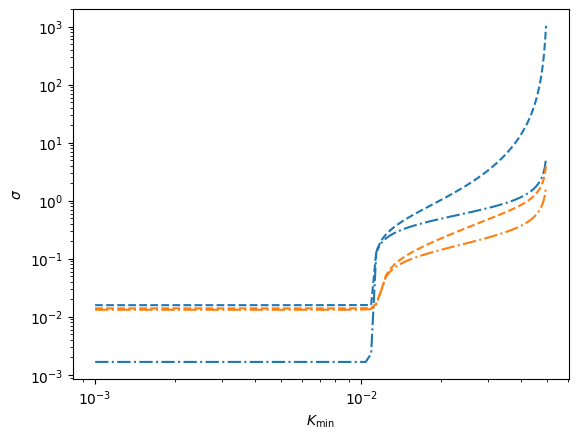

In [ ]:

cov_dict = {
          'Pgg': 'b10**2*Plin+1/nhalo',
          'Pgn': 'b10*new_bias*Plin+sh_bis',
          'Pnn': '0',
        }

errs_un, errs, temp_cov_A = get_forecast(cov_dict, variables_list_fisher = ["b10"])
ind = 0
#p = plt.loglog(Ks[:-1], errs[:, ind, ind])
#plt.loglog(Ks, errs_un[:, ind, ind], ls = ":", color = p[0].get_color())


cov_dict = {
          'Pgg': 'b10**2*Plin+1/nhalo',
          #'Pgn': 'b10*new_bias*Plin+sh_bis',
          #'Pnn': '0',
        }

errs_un, errs, temp_cov_B = get_forecast(cov_dict, variables_list_fisher = ["b10"])
ind = 0
#p = plt.loglog(Ks[:-1], errs[:, ind, ind])
#plt.loglog(Ks, errs_un[:, ind, ind], ls = ":", color = p[0].get_color())


cov_dict = {
          'Pgg': 'b10**2*Plin+1/nhalo',
          'Pgn': 'b10*new_bias*Plin+sh_bis',
          'Pnn': '0',
        }

errs_un, errs, temp_cov_C = get_forecast(cov_dict, variables_list_fisher = ["b10", "e"])
ind = 0
#p = plt.loglog(Ks[:-1], errs[:, ind, ind])
#plt.loglog(Ks, errs_un[:, ind, ind], ls = ":", color = p[0].get_color())

ind = 1
p = plt.loglog(Ks[:-1], errs[:, ind, ind], ls = "--")
plt.loglog(Ks, errs_un[:, ind, ind], ls = "-.", color = p[0].get_color())



cov_dict = {
          'Pgg': 'b10**2*Plin+1/nhalo',
          'Pgn': 'b10*new_bias*Plin',
          'Pnn': 'new_bias**2*Plin',
        }

errs_un, errs, temp_cov_D = get_forecast(cov_dict, variables_list_fisher = ["b10", "e"])
ind = 0
#p = plt.loglog(Ks[:-1], errs[:, ind, ind])
#plt.loglog(Ks, errs_un[:, ind, ind], ls = ":", color = p[0].get_color())

ind = 1
p = plt.loglog(Ks[:-1], errs[:, ind, ind], ls = "--")
plt.loglog(Ks, errs_un[:, ind, ind], ls = "-.", color = p[0].get_color())

plt.ylabel("$\sigma$")
plt.xlabel("$K_{\mathrm{min}}$")

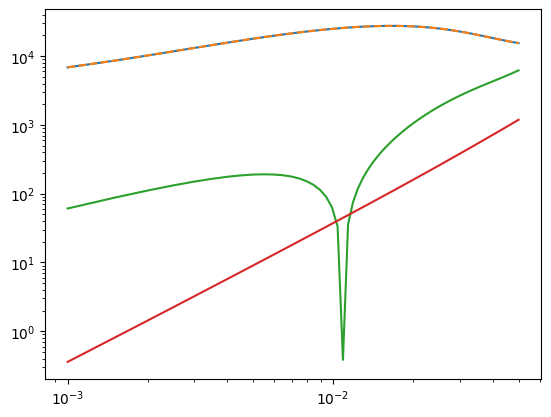

In [ ]:
plt.loglog(Ks, temp_cov_A[0, 0])
plt.loglog(Ks, temp_cov_B[0, 0], ls = "--")

plt.loglog(Ks, abs(temp_cov_A[0, 1]))

plt.loglog(Ks, abs(out_cross_shot[("n", "n")]*out[("n", "n")]**-1))